# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

**My answer for Q1**

1. I use these models when the outcome does not fit nicely with a regular straight-line prediction. A good example is a yes/no outcome, because the model should give a probability between `0` and `1`. Logistic regression handles this by making a linear score first, then passing it through the logistic function so the final answer behaves like a probability.

2. Cross entropy is a good loss function for classification because it looks at how much probability the model gave to the correct class. If the model is very sure but chooses the wrong class, the loss gets large. If it gives high probability to the correct class, the loss stays small. That matches the main goal of a classification model pretty well.

3. **False**, if we are talking about the final probability. Logistic regression has a linear piece inside it, since it starts with a weighted sum of the features. After that score goes through the logistic curve, the probability is no longer a straight-line function of the inputs.

4. **False.** Logistic regression can definitely be used for classification. It first gives probabilities, and then we can turn those probabilities into classes by using a cutoff such as `0.5`.

5. Not exactly. In logistic regression, a coefficient does not give a fixed change in probability the way it would in an ordinary linear model. The coefficient gives the change in log odds for a one-unit increase in that variable, while the actual probability change depends on where the observation already is on the probability curve.

6. **False.** Feature engineering can still matter. Logistic regression is only simple in the log-odds part of the model, so better coding, transformations, or interaction terms can still help when the real relationship is not very simple.

7. **False.** Logistic regression is useful for binary or categorical outcomes, but it does not replace ordinary least squares for every problem. If the target is a continuous numeric variable, ordinary least squares can still be the better choice.


**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


Missing values by column:
Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64

Logistic regression coefficients:
                   feature  coefficient
0                   Debtor     0.527137
1  Tuition fees up to date    -2.605617
2       Scholarship holder    -1.242299
3        Age at enrollment     0.049841

Average effect of being up to date on tuition on dropout probability:
-0.5233479695419885

Ages where tuition status reduces dropout probability the most:
Age at enrollment
22   -0.544791
21   -0.543064
23   -0.542678
20   -0.540436
24   -0.538071
19   -0.537309
18   -0.534191
25   -0.534188
26   -0.533585
27   -0.530360
Name: tuition_effect, dtype: float64


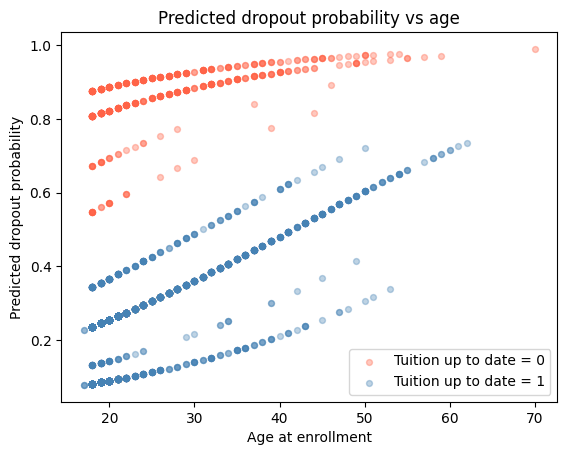


Logistic regression confusion matrix:
[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


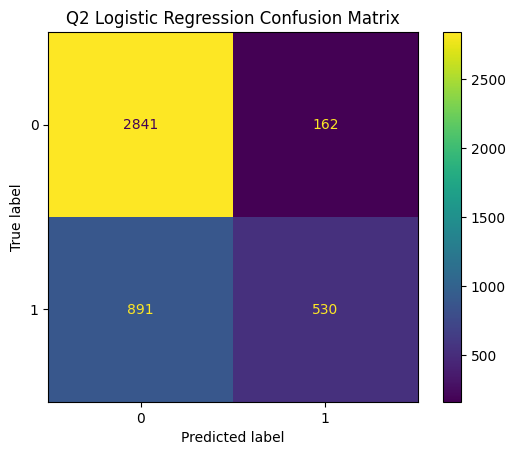


Linear model accuracy: 0.7633363471971067
Range of linear-model predictions: (np.float64(0.058320350225742), np.float64(1.3349535706758622))


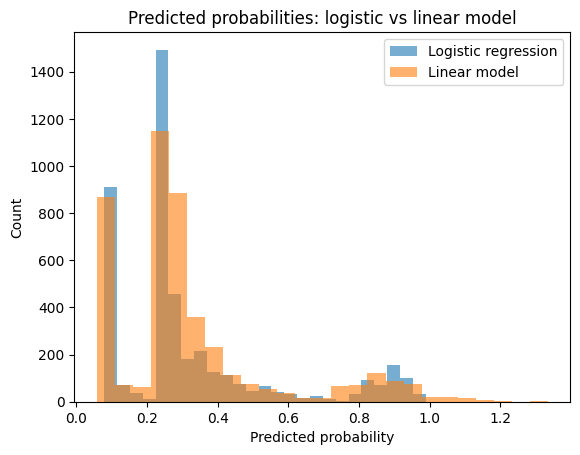


Multinomial confusion matrix (rows=true, cols=predicted):
          Dropout  Enrolled  Graduate
Dropout      1054         0       367
Enrolled      280         0       514
Graduate      146         0      2063

Predicted classes used by hard classification:
Graduate    2944
Dropout     1480
Name: count, dtype: int64

First five predicted probability rows:
    Dropout  Enrolled  Graduate
0  0.680560  0.210486  0.108954
1  0.706615  0.145494  0.147892
2  0.954343  0.040341  0.005316
3  0.117346  0.176786  0.705867
4  0.183691  0.212551  0.603758


In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix

warnings.filterwarnings('ignore', category=FutureWarning)

# Load the student data and keep just the variables needed for this question.
df = pd.read_csv('data.csv', sep=';')
cols = [
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'Age at enrollment',
    'Curricular units 1st sem (approved)',
    'Target',
]
df = df[cols].copy()

print('Missing values by column:')
print(df.isna().sum())

# For the binary model, dropout is 1 and every other outcome is 0.
df['dropout'] = (df['Target'] == 'Dropout').astype(int)

features = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']
X = df[features].copy()
y = df['dropout']

# These predictors are already numeric. This line is just a safety step.
X = X.fillna(X.median(numeric_only=True))

# Fit the logistic regression for dropout probability.
logit = LogisticRegression(max_iter=2000, penalty=None)
logit.fit(X, y)

coef_table = pd.DataFrame({'feature': X.columns, 'coefficient': logit.coef_[0]})
print('\nLogistic regression coefficients:')
print(coef_table)

# Predict dropout probabilities for the observed data.
df['dropout_prob_logit'] = logit.predict_proba(X)[:, 1]

# To isolate tuition status, I predict each student twice and only change this one column.
X_tuition_0 = X.copy()
X_tuition_0['Tuition fees up to date'] = 0

X_tuition_1 = X.copy()
X_tuition_1['Tuition fees up to date'] = 1

df['prob_if_tuition_not_up_to_date'] = logit.predict_proba(X_tuition_0)[:, 1]
df['prob_if_tuition_up_to_date'] = logit.predict_proba(X_tuition_1)[:, 1]
df['tuition_effect'] = df['prob_if_tuition_up_to_date'] - df['prob_if_tuition_not_up_to_date']

print('\nAverage effect of being up to date on tuition on dropout probability:')
print(df['tuition_effect'].mean())

age_effect = df.groupby('Age at enrollment')['tuition_effect'].mean().sort_values()
print('\nAges where tuition status reduces dropout probability the most:')
print(age_effect.head(10))

for tuition_value, color in [(0, 'tomato'), (1, 'steelblue')]:
    mask = df['Tuition fees up to date'] == tuition_value
    plt.scatter(
        df.loc[mask, 'Age at enrollment'],
        df.loc[mask, 'dropout_prob_logit'],
        alpha=0.35,
        s=18,
        label=f'Tuition up to date = {tuition_value}',
        color=color,
    )
plt.xlabel('Age at enrollment')
plt.ylabel('Predicted dropout probability')
plt.title('Predicted dropout probability vs age')
plt.legend()
plt.show()

# Turn probabilities into hard predictions and check the confusion matrix.
logit_pred = logit.predict(X)
print('\nLogistic regression confusion matrix:')
print(confusion_matrix(y, logit_pred))
print('Accuracy:', accuracy_score(y, logit_pred))
ConfusionMatrixDisplay.from_predictions(y, logit_pred)
plt.title('Q2 Logistic Regression Confusion Matrix')
plt.show()

# Compare this with a linear model to see why logistic regression makes more sense for probabilities.
linear_model = LinearRegression()
linear_model.fit(X, y)
df['dropout_prob_linear'] = linear_model.predict(X)
linear_pred = (df['dropout_prob_linear'] >= 0.5).astype(int)

print('\nLinear model accuracy:', accuracy_score(y, linear_pred))
print('Range of linear-model predictions:', (df['dropout_prob_linear'].min(), df['dropout_prob_linear'].max()))

plt.hist(df['dropout_prob_logit'], bins=25, alpha=0.6, label='Logistic regression')
plt.hist(df['dropout_prob_linear'], bins=25, alpha=0.6, label='Linear model')
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.title('Predicted probabilities: logistic vs linear model')
plt.legend()
plt.show()

# Now use multinomial logistic regression for the original three Target classes.
X_multi = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']].copy()
y_multi = df['Target']
X_multi = X_multi.fillna(X_multi.median(numeric_only=True))

multinomial_model = LogisticRegression(max_iter=3000, penalty=None)
multinomial_model.fit(X_multi, y_multi)

multi_pred = multinomial_model.predict(X_multi)
multi_probs = multinomial_model.predict_proba(X_multi)
classes = multinomial_model.classes_

print('\nMultinomial confusion matrix (rows=true, cols=predicted):')
print(pd.DataFrame(confusion_matrix(y_multi, multi_pred, labels=classes), index=classes, columns=classes))
print('\nPredicted classes used by hard classification:')
print(pd.Series(multi_pred).value_counts())
print('\nFirst five predicted probability rows:')
print(pd.DataFrame(multi_probs[:5], columns=classes))


**My answer for Q2**

The first thing I checked was whether the selected columns had missing values. They all showed `0`, so for these variables there was nothing that needed to be filled in before fitting the model.

For the dropout logistic regression, the coefficient signs are the most useful part to interpret. `Debtor` is positive, which means being a debtor is connected to a higher predicted chance of dropping out. `Tuition fees up to date` and `Scholarship holder` are both negative, so those variables point toward a lower dropout probability. `Age at enrollment` is positive too, but it is much smaller, so age only moves the prediction a little in this model.

When I used `.predict_proba`, changing tuition status to up to date lowered predicted dropout probability by about `0.523` on average. The largest drops were mostly for students in their early twenties, with age `22` showing the biggest average reduction in this fitted model.

The logistic model had an accuracy of about `0.762`. The ordinary linear model was almost the same by accuracy, around `0.763`, but that does not make the linear model better here. Its fitted values went as high as about `1.335`, which is not valid for a probability. Because of that, logistic regression is the more appropriate model even though the accuracy numbers are very close.

For the three-class version of the problem, the hard class predictions only picked `Dropout` or `Graduate`. The model never chose `Enrolled` as the final class label. The probability table is still useful though, because it still gives a probability for every class, including `Enrolled`, instead of only showing the single most likely label.


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

Missing values by column:
Edema          0
Drug         106
Bilirubin      0
Stage          6
Status         0
dtype: int64

Logistic regression coefficients:
        feature  coefficient
0     Bilirubin    -0.288007
1       Edema_S    -0.789076
2       Edema_Y    -1.713609
3  Drug_Placebo     0.061436

Average drug effect on survival probability:
-0.011407586184842205

Average drug effect within bilirubin quintiles:
Bilirubin
(0.299, 0.7]   -0.010730
(0.7, 1.1]     -0.011174
(1.1, 2.0]     -0.012485
(2.0, 4.5]     -0.014015
(4.5, 28.0]    -0.008871
Name: drug_effect, dtype: float64


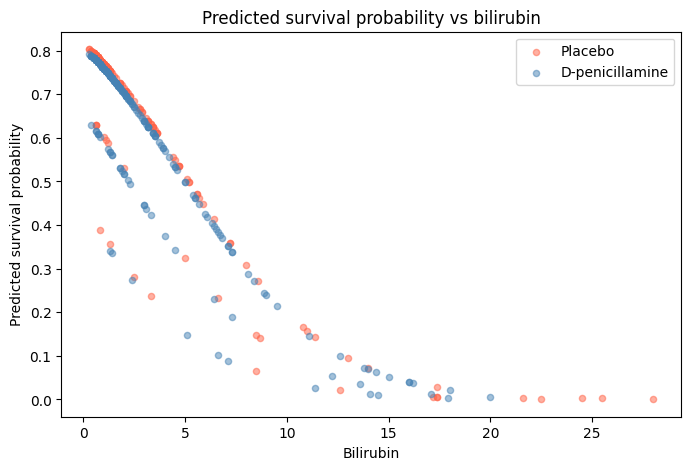


Logistic regression confusion matrix:
[[ 70  91]
 [ 21 236]]
Accuracy: 0.7320574162679426


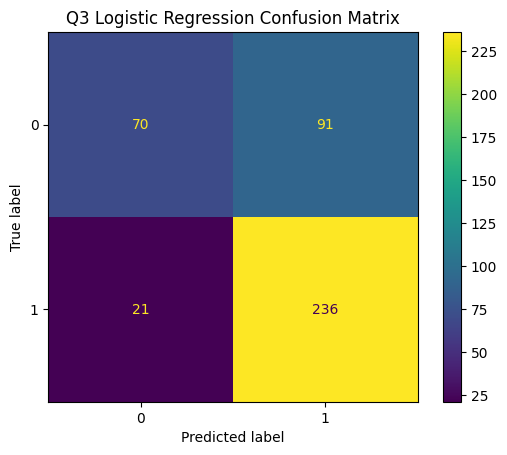


Linear model accuracy: 0.7248803827751196
Range of linear-model predictions: (np.float64(-0.48895755169502664), np.float64(0.7811518255286402))


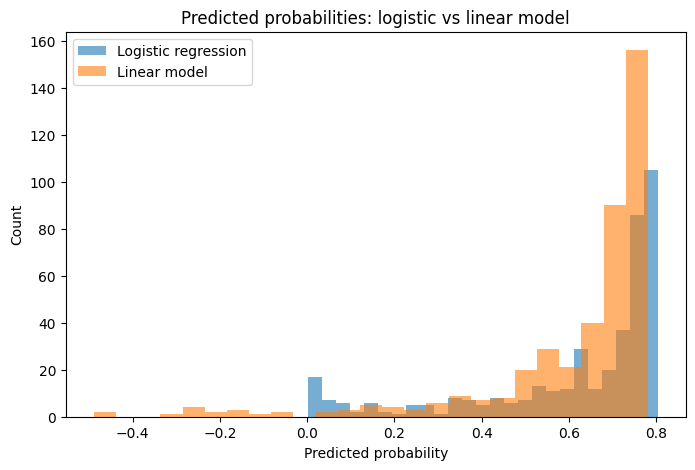


Stage confusion matrix (rows=true, cols=predicted):
   1  2    3   4
1  0  0   20   1
2  0  0   82  10
3  0  0  139  22
4  0  0   95  49

Predicted classes used by hard classification:
3    336
4     82
Name: count, dtype: int64

First five predicted probability rows:
              1         2         3         4
0  7.112953e-07  0.032876  0.120755  0.846368
1  6.943680e-02  0.252690  0.407875  0.269998
2  3.126036e-02  0.128141  0.340823  0.499776
3  2.759699e-02  0.126212  0.339230  0.506960
4  3.548455e-02  0.242345  0.415473  0.306697


In [3]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix

warnings.filterwarnings('ignore', category=FutureWarning)

# Load the cirrhosis data and keep only the variables used in this question.
df = pd.read_csv('cirrhosis.csv')
cols = ['Edema', 'Drug', 'Bilirubin', 'Stage', 'Status']
df = df[cols].copy()

print('Missing values by column:')
print(df.isna().sum())

# Fill missing predictors before modeling so the rows can be used.
df['Drug'] = df['Drug'].fillna(df['Drug'].mode()[0])
df['Stage'] = df['Stage'].fillna(df['Stage'].median())

# Survival is 1 for alive status codes and 0 for dead.
df['survival'] = df['Status'].isin(['C', 'CL']).astype(int)

# Fixing the category order makes the dummy columns come out consistently.
df['Edema'] = pd.Categorical(df['Edema'], categories=['N', 'S', 'Y'])
df['Drug'] = pd.Categorical(df['Drug'], categories=['D-penicillamine', 'Placebo'])

features = ['Edema', 'Drug', 'Bilirubin']
X = df[features].copy()
y = df['survival']

X_encoded = pd.get_dummies(X, columns=['Edema', 'Drug'], drop_first=True)

# Fit the logistic regression for survival.
logit = LogisticRegression(max_iter=2000)
logit.fit(X_encoded, y)

coef_table = pd.DataFrame({'feature': X_encoded.columns, 'coefficient': logit.coef_[0]})
print('\nLogistic regression coefficients:')
print(coef_table)

# Predicted survival probabilities from the model.
df['survival_prob_logit'] = logit.predict_proba(X_encoded)[:, 1]

# Compare the same rows under placebo and D-penicillamine so the drug variable is the only thing changing.
X_placebo = X.copy()
X_placebo['Drug'] = pd.Categorical(['Placebo'] * len(X_placebo), categories=['D-penicillamine', 'Placebo'])
X_placebo = pd.get_dummies(X_placebo, columns=['Edema', 'Drug'], drop_first=True)
X_placebo = X_placebo.reindex(columns=X_encoded.columns, fill_value=0)

X_drug = X.copy()
X_drug['Drug'] = pd.Categorical(['D-penicillamine'] * len(X_drug), categories=['D-penicillamine', 'Placebo'])
X_drug = pd.get_dummies(X_drug, columns=['Edema', 'Drug'], drop_first=True)
X_drug = X_drug.reindex(columns=X_encoded.columns, fill_value=0)

df['survival_if_placebo'] = logit.predict_proba(X_placebo)[:, 1]
df['survival_if_drug'] = logit.predict_proba(X_drug)[:, 1]
df['drug_effect'] = df['survival_if_drug'] - df['survival_if_placebo']

print('\nAverage drug effect on survival probability:')
print(df['drug_effect'].mean())

bilirubin_effect = pd.qcut(df['Bilirubin'], q=5, duplicates='drop')
print('\nAverage drug effect within bilirubin quintiles:')
print(df.groupby(bilirubin_effect, observed=False)['drug_effect'].mean())

plt.figure(figsize=(8, 5))
for drug_name, color in [('Placebo', 'tomato'), ('D-penicillamine', 'steelblue')]:
    mask = df['Drug'] == drug_name
    plt.scatter(
        df.loc[mask, 'Bilirubin'],
        df.loc[mask, 'survival_prob_logit'],
        alpha=0.5,
        s=20,
        label=drug_name,
        color=color,
    )
plt.xlabel('Bilirubin')
plt.ylabel('Predicted survival probability')
plt.title('Predicted survival probability vs bilirubin')
plt.legend()
plt.show()

# Hard classification results for the survival model.
logit_pred = logit.predict(X_encoded)
print('\nLogistic regression confusion matrix:')
print(confusion_matrix(y, logit_pred))
print('Accuracy:', accuracy_score(y, logit_pred))
ConfusionMatrixDisplay.from_predictions(y, logit_pred)
plt.title('Q3 Logistic Regression Confusion Matrix')
plt.show()

# Compare with a linear probability-style model, even though logistic regression is more natural here.
linear_model = LinearRegression()
linear_model.fit(X_encoded, y)
df['survival_prob_linear'] = linear_model.predict(X_encoded)
linear_pred = (df['survival_prob_linear'] >= 0.5).astype(int)

print('\nLinear model accuracy:', accuracy_score(y, linear_pred))
print('Range of linear-model predictions:', (df['survival_prob_linear'].min(), df['survival_prob_linear'].max()))

plt.figure(figsize=(8, 5))
plt.hist(df['survival_prob_logit'], bins=25, alpha=0.6, label='Logistic regression')
plt.hist(df['survival_prob_linear'], bins=25, alpha=0.6, label='Linear model')
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.title('Predicted probabilities: logistic vs linear model')
plt.legend()
plt.show()

# Model disease stage as a multiclass outcome using edema and bilirubin.
stage_df = df[['Edema', 'Bilirubin', 'Stage']].dropna().copy()
stage_df['Edema'] = pd.Categorical(stage_df['Edema'], categories=['N', 'S', 'Y'])
X_stage = stage_df[['Edema', 'Bilirubin']].copy()
y_stage = stage_df['Stage'].astype(int).astype(str)
X_stage_encoded = pd.get_dummies(X_stage, columns=['Edema'], drop_first=True)

stage_model = LogisticRegression(max_iter=4000, penalty=None)
stage_model.fit(X_stage_encoded, y_stage)

stage_pred = stage_model.predict(X_stage_encoded)
stage_probs = stage_model.predict_proba(X_stage_encoded)
stage_classes = stage_model.classes_

print('\nStage confusion matrix (rows=true, cols=predicted):')
print(pd.DataFrame(confusion_matrix(y_stage, stage_pred, labels=stage_classes), index=stage_classes, columns=stage_classes))
print('\nPredicted classes used by hard classification:')
print(pd.Series(stage_pred).value_counts())
print('\nFirst five predicted probability rows:')
print(pd.DataFrame(stage_probs[:5], columns=stage_classes))


**My answer for Q3**

The missing value check showed two issues in the predictors. `Drug` had `106` missing values, so I filled those with the most common drug category. `Stage` had `6` missing values, so I used the median stage before doing the parts where stage was being used as a predictor.

In the survival logistic regression, `Bilirubin` has a negative coefficient. I read that as higher bilirubin being associated with a lower predicted chance of survival. The edema indicators are negative as well, and `Edema_Y` is more negative than `Edema_S`, which makes sense because the more severe edema category is linked with worse predicted survival. `Drug_Placebo` is slightly positive, but the number is small, so I would not treat that as strong evidence that placebo is meaningfully better. It is just what this fitted model estimated from the sample.

The estimated drug effect, calculated as D-penicillamine minus placebo, is about `-0.011` on average. In plain terms, this model does not show a survival improvement from D-penicillamine. The effect is also negative across the bilirubin groups, so there is not an obvious bilirubin range where the drug looks helpful in this model.

The logistic regression accuracy was about `0.732`, while the linear model accuracy was about `0.725`. Those are fairly close, but the linear model produced some predictions below `0`, which cannot be real probabilities. That is the main reason logistic regression is the better fit for this type of outcome.

For the stage classification model, the hard predictions only selected stages `3` and `4`. Stages `1` and `2` were never picked as the final class. The predicted probability output gives a fuller picture because it still assigns some probability to all four stages.


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

**My answer for Q4**

1. In a regular linear model, the prediction is

   $$
   \hat{y} = b_0 + \sum_{k=1}^K b_k x_k.
   $$

   If I take the derivative with respect to the `k`th variable, I get

   $$
   \frac{\partial \hat{y}}{\partial x_k} = b_k.
   $$

   This means the interpretation is very direct. If `x_k` increases by one unit and the other variables stay the same, the prediction changes by `b_k`.

2. Logistic regression is different because the model turns the linear score into a probability:

   $$
   \hat{p} = \frac{e^{b \cdot x}}{1+e^{b \cdot x}}.
   $$

   Using the chain rule, the slope with respect to `x_k` is

   $$
   \frac{\partial \hat{p}}{\partial x_k} = \hat{p}(1-\hat{p})b_k.
   $$

   So the coefficient is not a fixed change in probability. The probability change depends on the current value of `\hat{p}`. The term `\hat{p}(1-\hat{p})` is biggest when `\hat{p}` is about `0.5`, where it equals `0.25`. Around that point, a one-unit increase in `x_k` changes the probability by roughly one fourth of `b_k`.

3. The cleanest interpretation comes from the log-odds version:

   $$
   \log\left(\frac{\hat{p}}{1-\hat{p}}\right) = b_0 + \sum_{k=1}^K b_k x_k.
   $$

   Taking the derivative gives

   $$
   \frac{\partial}{\partial x_k}\log\left(\frac{\hat{p}}{1-\hat{p}}\right)=b_k.
   $$

   So in logistic regression, `b_k` is the exact change in log odds for a one-unit increase in `x_k`, holding the other variables fixed.


## AI Reference

AI (ChatGPT Codex) was used to help generate and clean up my code for Q2 and Q3. Also AI helped me verify formulas for Q4. All written answers are my own. I tested, ran, and submitted all code. 